# Illustration du principe de l'interpolation

## Principe

In [1]:
import numpy as np
import skimage.io as io
import skimage.transform as tf
import matplotlib.pyplot as plt
from skimage import transform

In [2]:
# Grille de pixels
def display_grid(xo=0, yo=0, Nx=1, Ny=1, a=0, dx=1, dy=1, color="#444", linewidth=1):
    # Dessine une grille de pixels
    # xo, yo : coordonnées de l'origine de la grille
    # Nx, Ny : taille des pixels
    # a      : angle d'inclinaison de la grille
    # dx, dy : taille des pixels
    # ...    : paramètres des lignes de la grille
    for i in range(Nx+1):
        x1 = (xo-.5) + (i*dx)*np.cos(a)
        y1 = (yo-.5) + (i*dy)*np.sin(a)
        x2 = (xo-.5) + (i*dx)*np.cos(a) - (Ny*dy)*np.sin(a)
        y2 = (yo-.5) + (i*dy)*np.sin(a) + (Ny*dy)*np.cos(a)
        plt.plot([x1, x2], [y1, y2], color=color, linewidth=linewidth)
    for j in range(Ny+1):
        x1 = (xo-.5) - (j*dx)*np.sin(a)
        y1 = (yo-.5) + (j*dy)*np.cos(a)
        x2 = (xo-.5) - (j*dx)*np.sin(a) + (Nx*dx)*np.cos(a)
        y2 = (yo-.5) + (j*dy)*np.cos(a) + (Nx*dx)*np.sin(a)
        plt.plot([x1, x2], [y1, y2], color=color, linewidth=linewidth)

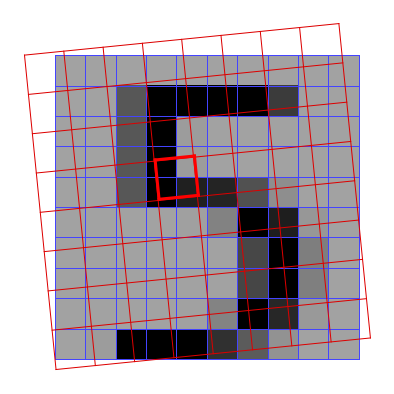

In [3]:
img = io.imread("../_static/figs/five.png")
img = tf.resize(img, (10,10))

# Géométrie de l'interpolation
plt.figure(figsize=(7,7))
plt.imshow(img, cmap="gray")
display_grid(Nx=10, Ny=10, color="#44f")
display_grid(xo=-1,  yo=0,  Nx=8, Ny=8, a=-.1, dx=1.3, dy=1.3, color="#d00")
display_grid(xo=3.3, yo=3.45,             a=-.1, dx=1.3, dy=1.3, color="#f00", linewidth=3)
plt.axis('off')
plt.savefig("interpolation.png", bbox_inches='tight')
plt.show()

## Exemple sur des images

In [4]:
def display_interp(img, tform, order, filename):
    
    # Transformation
    interpolated = transform.warp(img, tform, order=order, output_shape=(N,N))
    
    # Affichage
    fig, ax = plt.subplots(1,2,figsize=(8,16))
    ax[0].imshow(img, cmap="gray", vmin=0, vmax=1)
    ax[1].imshow(interpolated, cmap="gray", vmin=0, vmax=1)
    plt.savefig(filename, bbox_inches='tight')

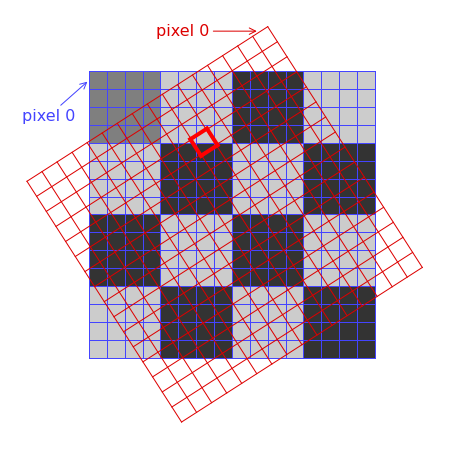

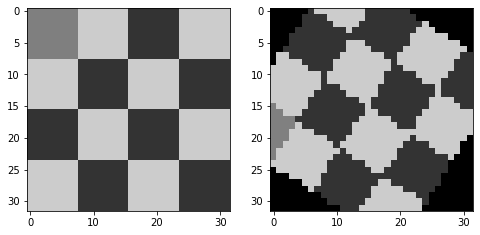

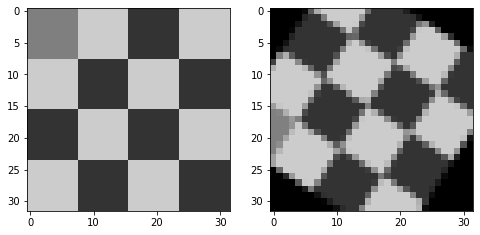

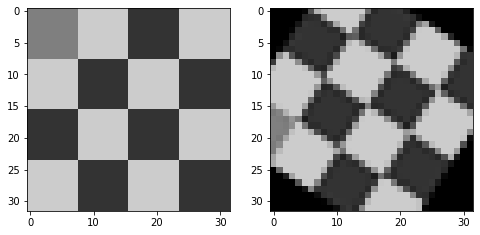

In [5]:
# Image
N, S = 32, 8
y, x = np.mgrid[0:N, 0:N]
pattern = (x//S + y//S) % 2
img = pattern*.6 + .2
img[:S,:S] = .5
# img = np.ones((N,N,3))
# img[:,:,0] = pattern
# img[:,:,1] = pattern
# img[:S,:S,1] = 1

# Transformation
scale = 1
rotation = 1
translation = (20, -5)#(N/2, -20)
tform = transform.SimilarityTransform( scale=scale, rotation=rotation, translation=translation )

# Dessine une grille de pixels
xo, yo = translation
Nx, Ny = N//2, N//2
a = rotation
dx, dy = 2, 2
plt.figure(figsize=(8,8))
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
display_grid(xo=0, yo=0, Nx=Nx, Ny=Ny, a=0, dx=dx, dy=dy, color='#44f')
display_grid(xo, yo, Nx, Ny, a, dx, dy, color='#d00')
display_grid(xo=13.2, yo=6.4, Nx=1, Ny=1, a=a, dx=dx*1.1, dy=dy*1.1, color='#f00', linewidth=4)
plt.axis('off')
plt.annotate("pixel 0", xy=(-.5,.5), xytext=(-8,5),
             color='#44f', fontsize=16, arrowprops=dict(arrowstyle="->", color='#44f'))
plt.annotate("pixel 0", xy=(18.5,-5), xytext=(7,-4.5),
             color='#d00', fontsize=16, arrowprops=dict(arrowstyle="->", color='#d00'))
plt.savefig("interp-grid-image.svg", bbox_inches='tight')

# Interpolation et résultat
for order in [0, 1, 3]:
    display_interp(img, tform, order, f"interp-{order}-image.svg")

## Méthodes d'interpolations

In [41]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate

F = 1
c0 = "#008800"
c1 = "#0000ff"
c2 = "#cc0000"

def myplot(x1, y1, x2, y2, xx,yy, K, kind):
    
    N = len(x1)
    
    # Interpolation 1D
    
    fig, ax = plt.subplots()
    
    # Grille
#     ax.xaxis.set_minor_locator(MultipleLocator(1/K))
#     ax.xaxis.grid(True,'minor', linewidth=1, linestyle=":", color=c2)

#     ax.xaxis.set_major_locator(MultipleLocator(1))
#     ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
#     ax.xaxis.grid(True,'major', linewidth=1,  linestyle="-", color=c1)
    
    # Courbe d'interpolation
    ax.plot(xx, yy, color='gray', linewidth=.5)

    # Special for cubic
    if kind == 'cubic':
        idx = range(10,20)
        ax.plot(xx[idx], yy[idx], color='gray', linewidth=3)
        for i in range(4):
            ax.annotate("", xy=(i,y1[i]+.05), xytext=(i,y1[i]+.15), arrowprops=dict(arrowstyle="->", color="C0", lw=3))
    
    # Données originales et interpolées
    ax.plot(x1, y1, color='C0', linewidth=0, markersize=8, markeredgewidth=2, marker="o", fillstyle='none', )
    ax.plot(x2, y2, color='r', linewidth=0, markersize=8, marker=".")

    ax.set_xlim(0,N-1)
    ax.set_ylim(0,1)
    ax.set_xticks(range(0,N))
    ax.set_yticks([0,1])
    
    plt.savefig(f"interp-{kind}-1d.svg", bbox_inches='tight')
    plt.show()
    
    # # Interpolation 2D
    # img = [np.concatenate( (y1,[1,1],y2) )]
    # fig, ax = plt.subplots(figsize=(15,2))
    # ax.imshow(img, vmin=0, vmax=1, cmap="gray", interpolation='none')
    # ax.plot([-.5,N-.5,N-.5,-.5,-.5],[-.5,-.5,.5,.5,-.5],'k')
    # ax.plot([(N+2)-.5,(N+N*K)-.5,(N+N*K)-.5,(N+2)-.5,(N+2)-.5],[-.5,-.5,.5,.5,-.5],'k')
    # ax.text(N+.5,0,"→", va="center", ha="center", fontsize=30)
    # ax.axis('off')
    # ax.set_xticks([])
    # ax.set_yticks([])
    # plt.savefig(f"interp-{kind}-2d.svg", bbox_inches='tight')
    # plt.show()

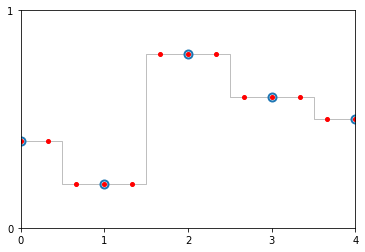

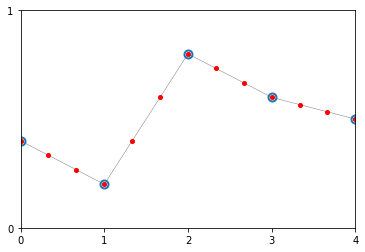

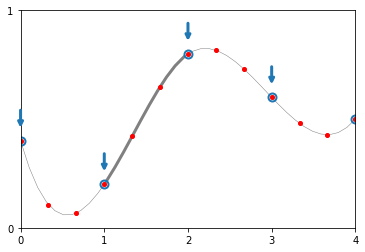

In [43]:
# Données
y1 = np.array([.4, .2, .8, .6, .5])
N = len(y1)
x1 = np.arange(N)

# Interpolation d'un facteur K
K = 3
x2 = np.arange(0, N-.999, 1/K)

# Interpolation linéaire
for kind in ['nearest', 'linear', 'cubic']:
    
    # Interpolation d'un facteur K
    f = interpolate.interp1d(x1, y1, kind=kind)
    y2 = f(x2)
    
    # Courbe d'interpolation
    xx = np.array([])
    yy = np.array([])
    if kind == 'nearest':
        for i in range(N):
            xx = np.append(xx, [x1[i]-.5,x1[i]+.5])
            yy = np.append(yy, [y1[i],y1[i]])
    if kind == 'linear':
        xx = x1
        yy = y1
    if kind == 'cubic':
        xx = np.linspace(0,N-1,40)
        yy = f(xx)
    
    myplot(x1, y1, x2, y2, xx, yy, K, kind)

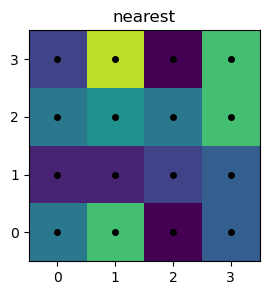

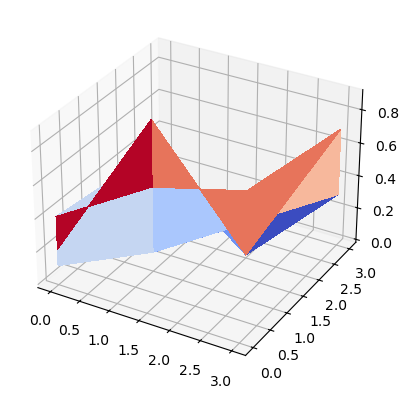

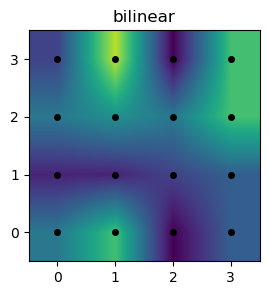

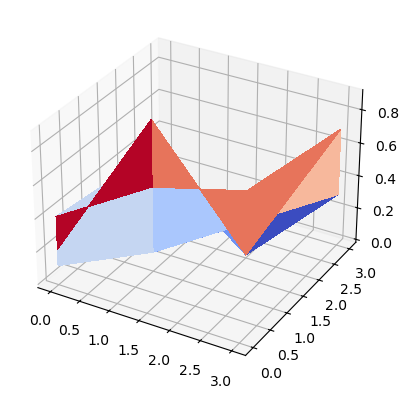

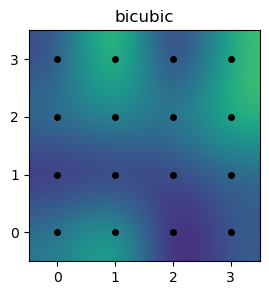

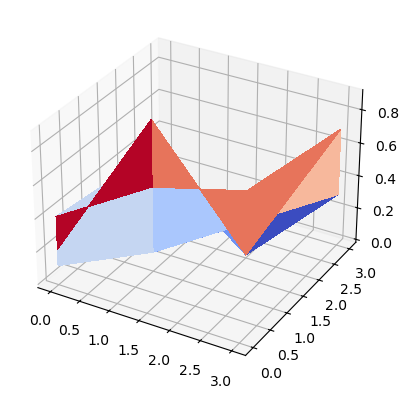

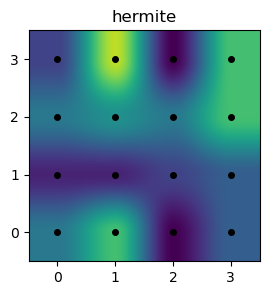

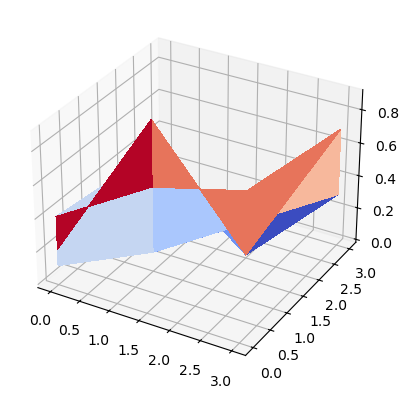

In [13]:
# Source : https://commons.wikimedia.org/wiki/File:Interpolation-bicubic.svg

# import sys
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import rcParams

# rcParams['font.size'] = 18

# Available interpolation methods:
# 'none', 'nearest', 'bilinear', 'bicubic', 'spline16',
# 'spline36', 'hanning', 'hamming', 'hermite', 'kaiser', 'quadric',
# 'catrom', 'gaussian', 'bessel', 'mitchell', 'sinc', 'lanczos'

METHODS = [ 'nearest', 'bilinear', 'bicubic', 'hermite' ]
FORMATS = [ 'png', 'pdf', 'svg' ]
COLORS  = 'viridis'

N = 4#5
np.random.seed(1)
grid = np.arange(0, N, 1)
data = np.round(np.random.rand(N, N), 1)
mesh = np.meshgrid(grid, grid)

for interp in METHODS:

    fig, ax = plt.subplots(1, 1, figsize=(5,3))

    ax.imshow(data, interpolation=interp, cmap=COLORS, vmin=0, vmax=1)
    ax.plot(mesh[0], mesh[1], marker='.', ms=8, color='k', lw=0)
    ax.set_title(interp)
    ax.set_xlim(grid.min()-0.5, grid.max()+0.5)
    ax.set_ylim(grid.min()-0.5, grid.max()+0.5)
    ax.set_xticks(grid)
    ax.set_yticks(grid)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
   
    # surf = 
    ax.plot_surface(grid, grid, data, cmap="coolwarm", linewidth=0, antialiased=False)
    # ax.set_zlim(-1.01, 1.01)
    # ax.zaxis.set_major_locator(LinearLocator(10))
    # ax.zaxis.set_major_formatter('{x:.02f}')

    # cax = fig.add_axes([0.125, 0.075, 0.75, 0.03])
    # cb = plt.colorbar(cax=cax, orientation='horizontal',
    #                   ticks=np.linspace(0, 1, 6))
    # cb.solids.set_edgecolor('face')

    # for ext in FORMATS:
    #     plt.savefig("{}_{}.{}".format(sys.argv[0], interp, ext))